<a href="https://colab.research.google.com/github/priyankakpal/Target-Analysis-Using-SQL-Tablue/blob/target-data/AdEase_TimeSeries_BusinessCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the dataset and doing usual exploratory analysis steps like checking the structure & characteristics of the dataset

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/train_1.csv')
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [164]:
df.columns

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25', '2016-12-26',
       '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31'],
      dtype='object', length=551)

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB


In [166]:
df.shape

(145063, 551)

In [167]:
df.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


In [168]:
df.isna().sum()

,0
Page,0
2015-07-01,20740
2015-07-02,20816
2015-07-03,20544
2015-07-04,20654
...,...
2016-12-27,3701
2016-12-28,3822
2016-12-29,3826
2016-12-30,3635


Exploratory Data Analysis

Separating the data

Analyzing and visualizing the data

Getting inferences

In [169]:
data = df.isna().sum().reset_index()['index'].iloc[1:]

In [170]:
for i in data:
  df[i] = df[i].interpolate(method='linear')

Handing missing value through mean is not impact that much so linear interploate method will work fine

In [171]:
import re
pattern = r'^(.*)\.(.*)\.org_(.*)$'

# Perform the regex search
df['Value'] = df['Page'].str.extract(pattern)[0].reset_index()[0]

<ipython-input-171-c2b7d5b6b360>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Value'] = df['Page'].str.extract(pattern)[0].reset_index()[0]


In [172]:
df['Code'] = df['Value'].str.rsplit('_',n=1).str.get(-1).reset_index()['Value']

<ipython-input-172-ec525a613e52>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Code'] = df['Value'].str.rsplit('_',n=1).str.get(-1).reset_index()['Value']


In [173]:
df['Access_Origin']=df['Page'].str.extract(pattern)[2].str.rsplit('_',n=1).str.get(-1)

<ipython-input-173-edfa60796259>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Access_Origin']=df['Page'].str.extract(pattern)[2].str.rsplit('_',n=1).str.get(-1)


In [174]:
df['Access_Type']=df['Page'].str.extract(pattern)[2].str.rsplit('_',n=1).str.get(-2)

<ipython-input-174-d3bcbdb513ee>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Access_Type']=df['Page'].str.extract(pattern)[2].str.rsplit('_',n=1).str.get(-2)


In [175]:
df['Title'] = df['Value'].str.rsplit('_',n=1).str.get(-2)

<ipython-input-175-aa9f2d0efc27>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Title'] = df['Value'].str.rsplit('_',n=1).str.get(-2)


Did the feature engineering for extracting title, access type and access origin using regular expression

In [176]:
df = df.drop(columns=['Value'])

In [177]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Code,Access_Origin,Access_Type,Title
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,zh,spider,all-access,2NE1
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,zh,spider,all-access,2PM
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,zh,spider,all-access,3C
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,zh,spider,all-access,4minute
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,23.5,10.0,7.0,49.5,12.0,17.0,9.5,13.0,17.5,...,3.0,11.0,27.0,13.0,36.0,10.0,zh,spider,all-access,52_Hz_I_Love_You


By observing the daily data for pages it's seems that outlier are more on each days

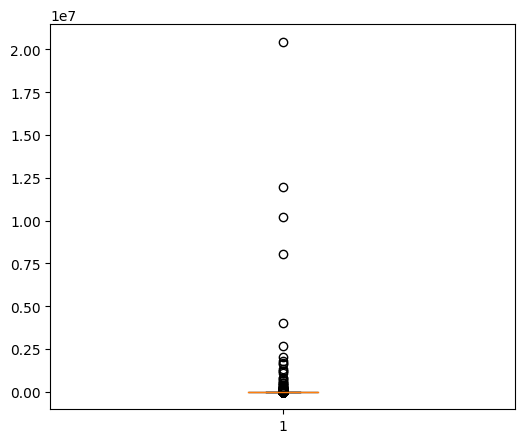

In [178]:
plt.figure(figsize=(6, 5))
plt.boxplot(df['2015-07-04'],patch_artist=True)
plt.show()

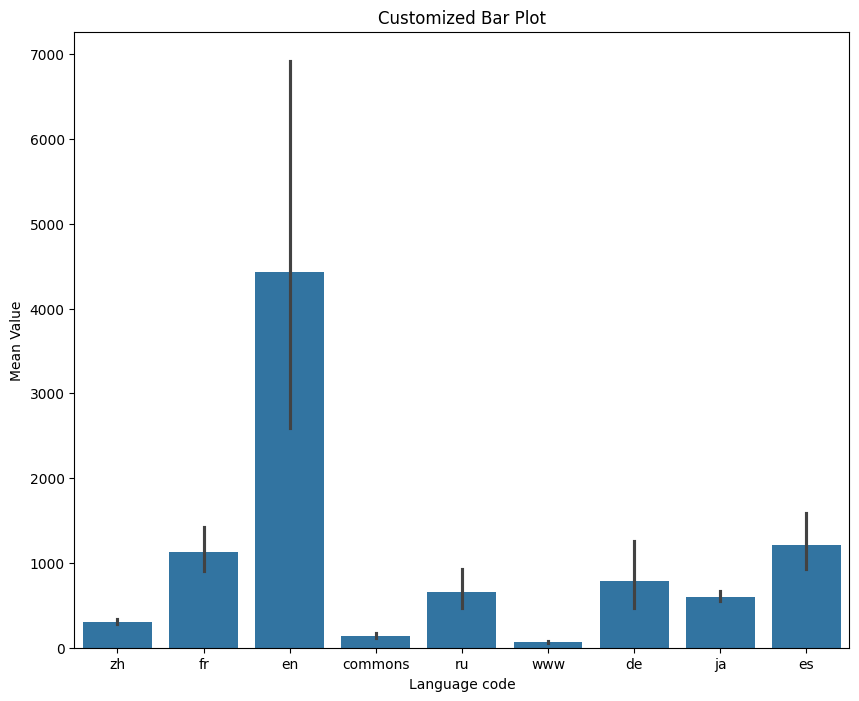

In [179]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df, y='2015-07-01', x='Code', estimator='mean')

plt.title('Customized Bar Plot')
plt.xlabel('Language code')
plt.ylabel('Mean Value')
plt.show()


Highest viewer are not en language code

In [180]:
final_df = df.groupby('Code')[data].mean().reset_index()

In [181]:
final_df

,Code,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,commons,139.856785,144.913011,138.908737,120.374460,130.028795,146.576981,154.215178,161.330916,143.856604,...,209.037044,250.355045,208.741213,256.496968,279.400900,239.207864,277.409048,239.363619,261.886594,230.911795
1,de,790.590708,775.655888,745.781675,678.666147,791.054515,887.303849,855.529452,864.831121,828.418496,...,864.629886,874.156144,829.856688,1309.671699,1230.913733,1116.103251,1063.900065,1022.153879,975.896722,914.112471
2,en,4427.708334,4392.444278,4166.937545,4322.986667,4482.500642,4836.974028,4551.901717,4284.549299,4393.510880,...,5009.076987,4698.212627,4984.702257,5154.317944,5783.854405,6063.200286,5889.543575,6268.441202,5217.368425,5139.305521
3,es,1209.966616,1160.710520,1056.724289,992.046323,1077.227063,1226.330309,1196.822634,1166.162328,1139.909733,...,1006.592793,1051.534473,1020.124067,1027.688535,1229.270808,1158.401166,1205.359265,1134.708330,832.054375,796.098443
4,fr,1129.034804,502.047865,484.547462,526.252510,507.830786,528.904187,512.974153,507.310840,500.392004,...,654.085187,645.976688,620.085271,668.159055,938.333305,859.794574,776.484440,754.271205,702.872149,647.605466
5,ja,601.360077,687.995484,616.659299,776.318452,750.043471,666.307358,632.757337,629.448948,615.581472,...,693.498165,992.806373,881.110543,840.592555,800.925236,809.202535,810.996280,887.976041,959.556825,1215.738192
6,ru,651.452513,655.053777,609.369040,572.553909,628.859743,654.493056,639.950094,636.111450,652.435897,...,904.258687,889.358707,878.284749,1210.272633,1115.309712,1003.665424,934.810545,900.150945,805.680469,883.976202
7,www,62.455688,67.934622,58.759599,55.877146,62.963038,70.815116,76.201927,65.650363,58.358554,...,50.066644,75.832877,71.296027,77.254247,44.610274,47.360959,115.909726,46.369521,61.611096,56.987534
8,zh,302.355734,268.117246,267.042942,259.622370,277.441749,285.467030,285.423816,301.522357,293.926511,...,348.677404,343.924488,364.721371,385.032910,380.080504,379.421063,382.057316,354.920570,359.611527,369.184021


In [182]:
final_df = final_df.melt(id_vars='Code', value_vars=final_df.iloc[:,1:].columns, var_name='Date',value_name='Page_View')

In [183]:
final_df

,Code,Date,Page_View
0,commons,2015-07-01,139.856785
1,de,2015-07-01,790.590708
2,en,2015-07-01,4427.708334
3,es,2015-07-01,1209.966616
4,fr,2015-07-01,1129.034804
...,...,...,...
4945,fr,2016-12-31,647.605466
4946,ja,2016-12-31,1215.738192
4947,ru,2016-12-31,883.976202
4948,www,2016-12-31,56.987534


In [184]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4950 entries, 0 to 4949
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       4950 non-null   object 
 1   Date       4950 non-null   object 
 2   Page_View  4950 non-null   float64
dtypes: float64(1), object(2)
memory usage: 116.1+ KB


In [185]:
final_df['Date'] = pd.to_datetime(final_df['Date'])

In [186]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4950 entries, 0 to 4949
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Code       4950 non-null   object        
 1   Date       4950 non-null   datetime64[ns]
 2   Page_View  4950 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 116.1+ KB


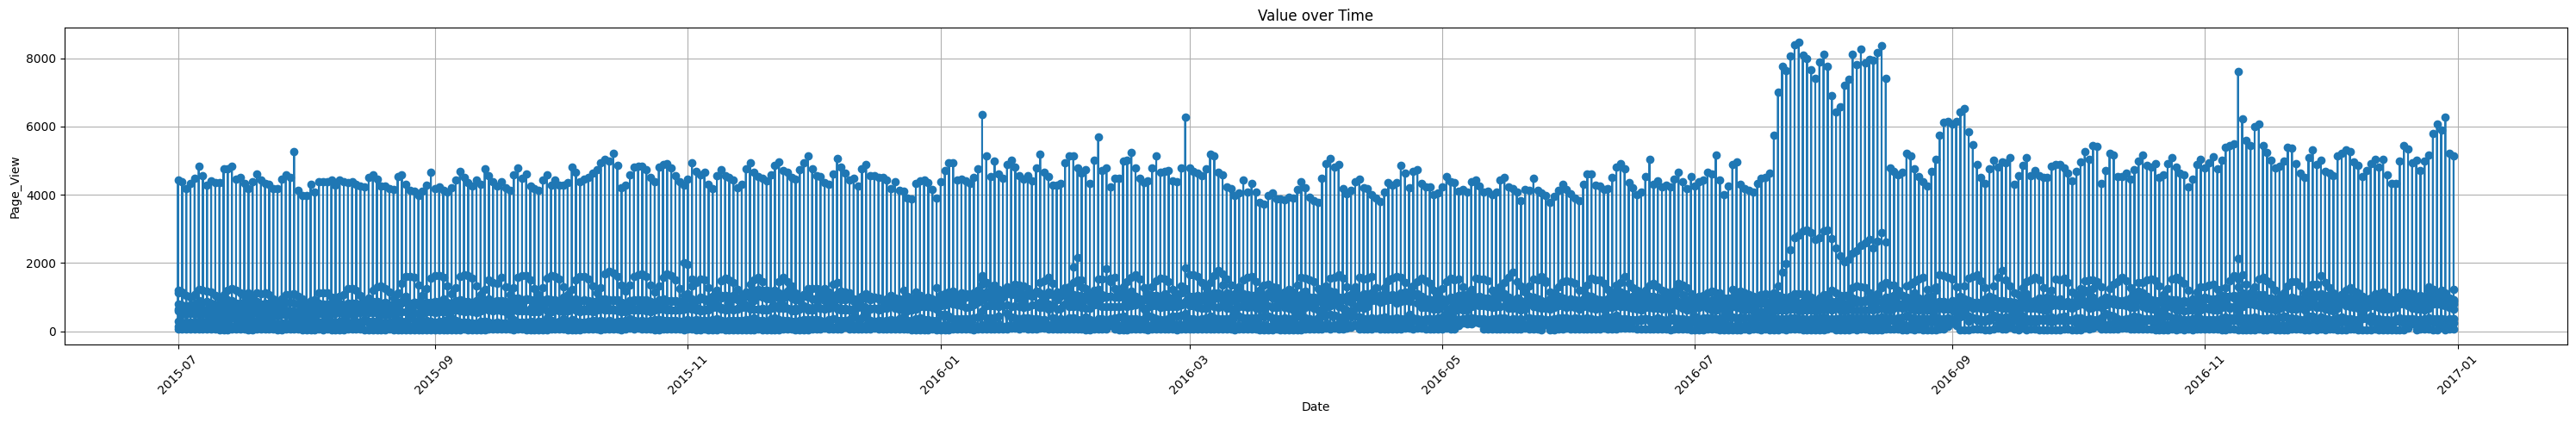

In [187]:
plt.figure(figsize=(30, 5))
plt.plot(final_df['Date'], final_df['Page_View'], marker='o')

# Customize the plot
plt.title('Value over Time')
plt.xlabel('Date')
plt.ylabel('Page_View')
plt.grid()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Display the plot
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

ploting the hall data it's seems that the data are almost stable just 2017 on 8th month data are high

In [188]:
final_df['Date'].unique()

<DatetimeArray>
['2015-07-01 00:00:00', '2015-07-02 00:00:00', '2015-07-03 00:00:00',
 '2015-07-04 00:00:00', '2015-07-05 00:00:00', '2015-07-06 00:00:00',
 '2015-07-07 00:00:00', '2015-07-08 00:00:00', '2015-07-09 00:00:00',
 '2015-07-10 00:00:00',
 ...
 '2016-12-22 00:00:00', '2016-12-23 00:00:00', '2016-12-24 00:00:00',
 '2016-12-25 00:00:00', '2016-12-26 00:00:00', '2016-12-27 00:00:00',
 '2016-12-28 00:00:00', '2016-12-29 00:00:00', '2016-12-30 00:00:00',
 '2016-12-31 00:00:00']
Length: 550, dtype: datetime64[ns]

In [189]:
d = final_df[final_df['Date'].dt.year==2015]

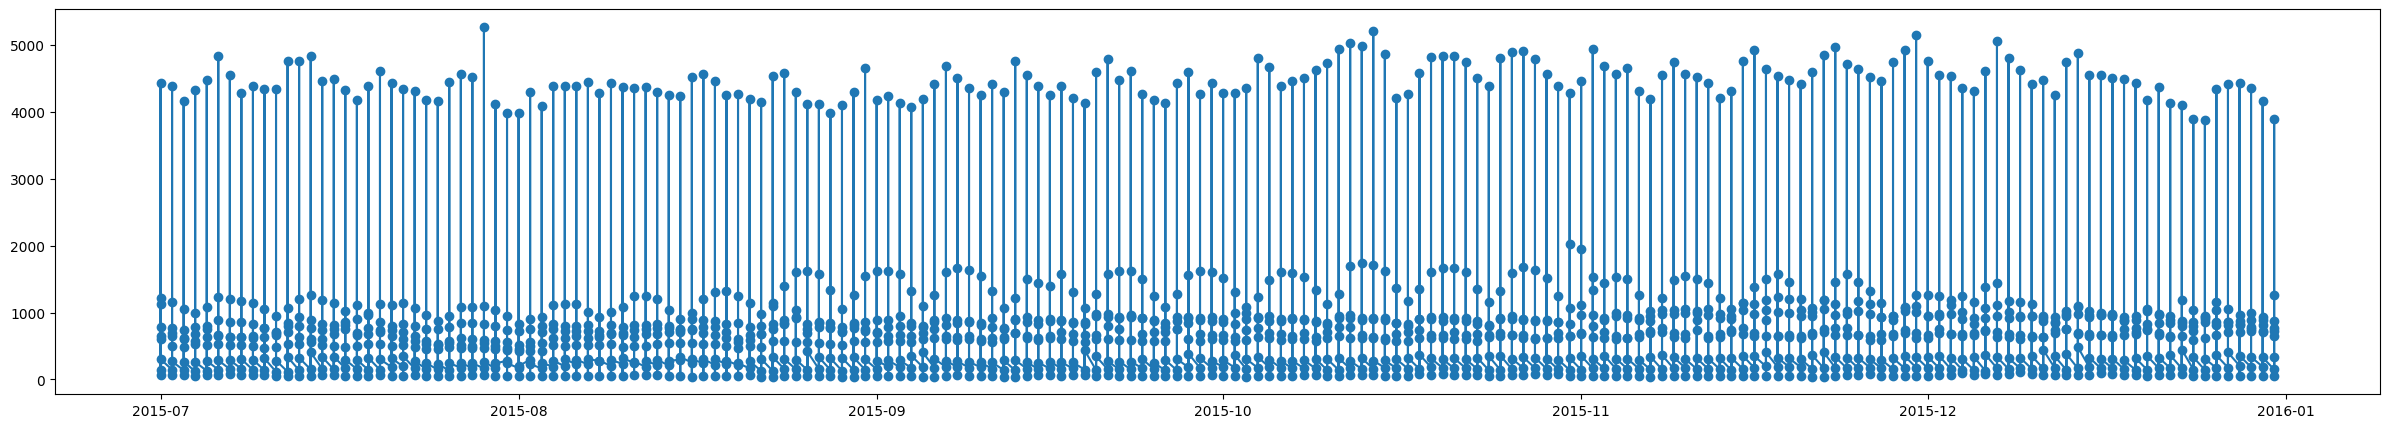

In [190]:
plt.figure(figsize=(30, 5))
plt.plot(d['Date'], d['Page_View'], marker='o',linestyle='-')

In [191]:
m = final_df[(final_df['Date'].dt.year==2015) & (final_df['Date'].dt.month==7)]

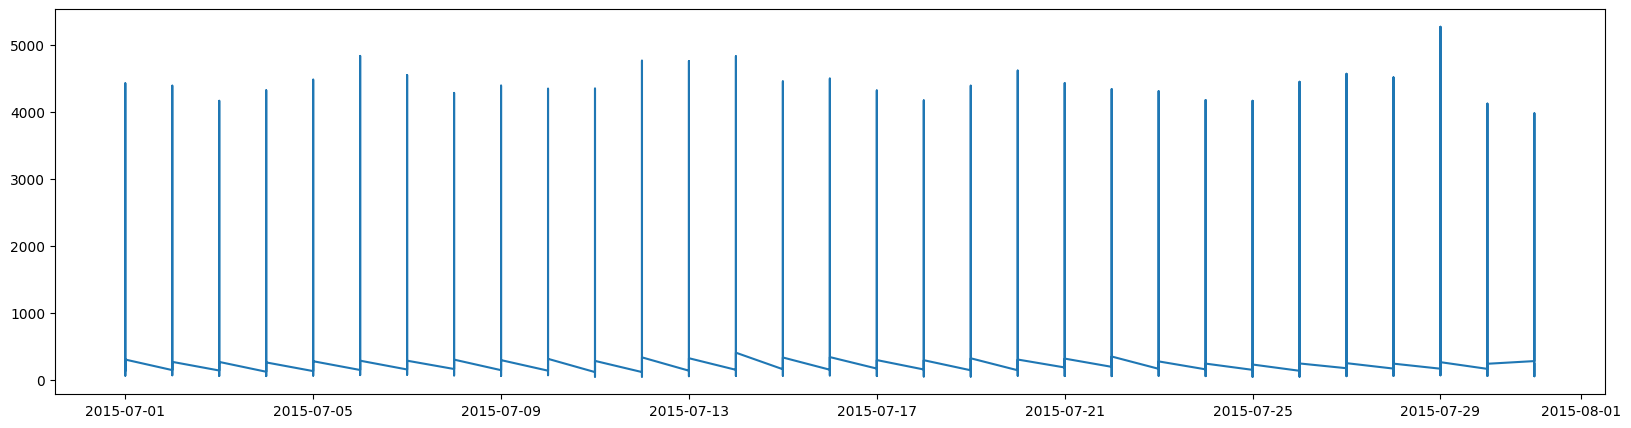

In [192]:
plt.figure(figsize=(20, 5))
plt.plot(m['Date'], m['Page_View'])

One year data of 2015 provide the inferences of stationarity data

Checking stationarity

Formatting the data for the model

Dickey fuller test

Decomposition

Differencing

In [193]:
final_df.set_index('Date',inplace=True)

In [194]:
final_df

,Code,Page_View
Date,,
2015-07-01,commons,139.856785
2015-07-01,de,790.590708
2015-07-01,en,4427.708334
2015-07-01,es,1209.966616
2015-07-01,fr,1129.034804
...,...,...
2016-12-31,fr,647.605466
2016-12-31,ja,1215.738192
2016-12-31,ru,883.976202


In [195]:
import statsmodels.api as sm

def stationarity_status(data, significate_level=0.05):
  pvalue = sm.tsa.stattools.adfuller(data)[1]
  if pvalue <= significate_level:
    print('Sequence is stationary')
  else:
    print('Sequence is not stationary')

stationarity_status(final_df.Page_View)

Sequence is stationary


In [196]:
print(type(final_df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [197]:
final_df

,Code,Page_View
Date,,
2015-07-01,commons,139.856785
2015-07-01,de,790.590708
2015-07-01,en,4427.708334
2015-07-01,es,1209.966616
2015-07-01,fr,1129.034804
...,...,...
2016-12-31,fr,647.605466
2016-12-31,ja,1215.738192
2016-12-31,ru,883.976202


In [198]:
final_df['Page_View'] = final_df['Page_View'].round()

In [199]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4950 entries, 2015-07-01 to 2016-12-31
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       4950 non-null   object 
 1   Page_View  4950 non-null   float64
dtypes: float64(1), object(1)
memory usage: 116.0+ KB


In [200]:
final_df = final_df.reset_index()
data_de = final_df[['Date','Page_View']]

In [201]:
data_de = data_de.groupby('Date')['Page_View'].sum().round()

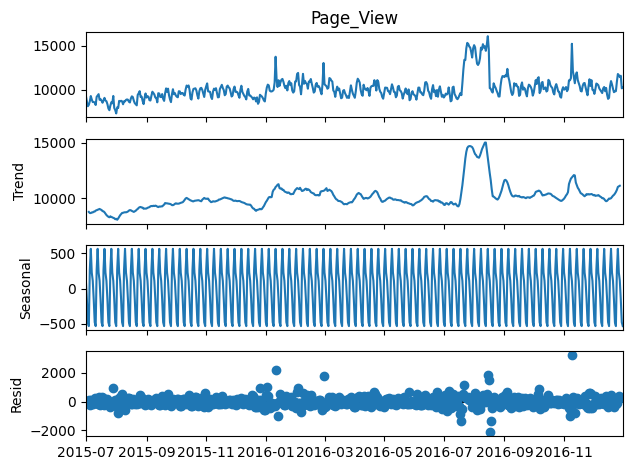

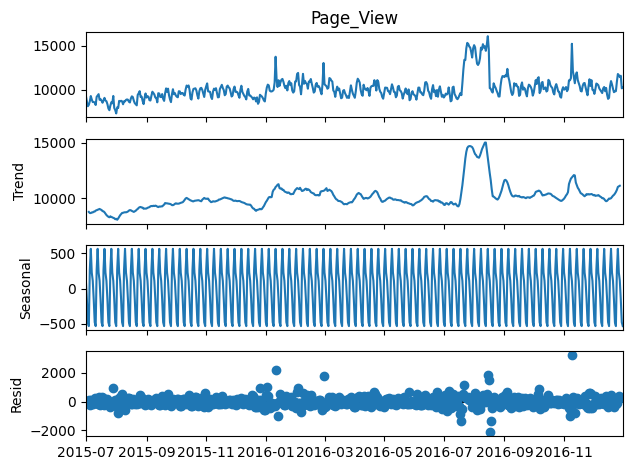

In [202]:
model = sm.tsa.seasonal_decompose(data_de)
model.plot()

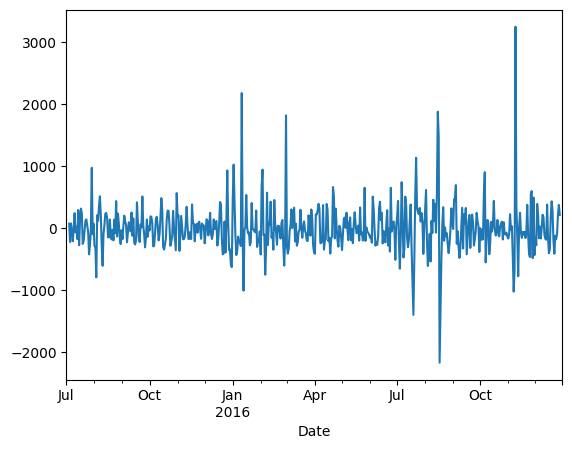

In [203]:
model.resid.plot();

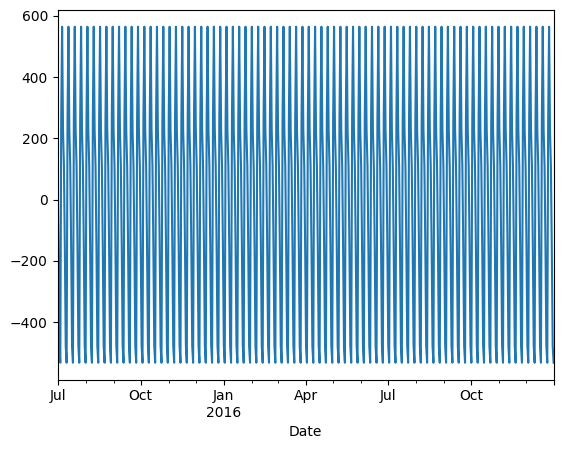

In [204]:
model.seasonal.plot();

In this data no seasonality and data are stable there is no trend no seasonality

In [215]:
data_de = data_de.reset_index()

doing differencing using 1 not need but just for testing how data will perform after stationary data

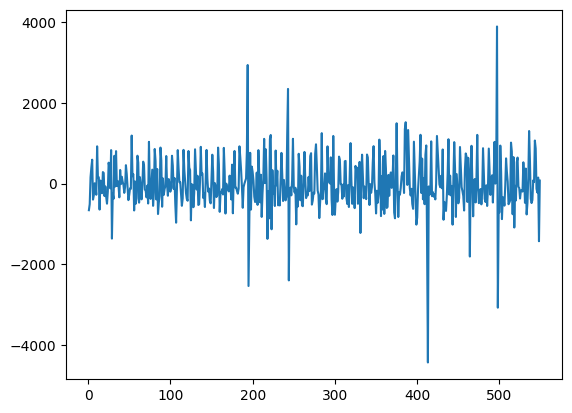

In [216]:
data_de.Page_View.diff(1).plot();

In [217]:
stationarity_status(data_de['Page_View'].diff(1).dropna())

Sequence is stationary


Creating model training and forecasting with ARIMA, SARIMAX

ACF and PACF plot.

Training the model.

Forecasting for different languages/regions.

Plotting the final results

In [221]:
data_de.set_index('Date', inplace=True)

In [223]:
train_max_date = data_de.index[-12]

train_x = data_de.loc[data_de.index < data_de.index[-12]].copy()
test_x = data_de.loc[data_de.index >= data_de.index[-12]].copy()

In [224]:
train_x.tail(10)

,Page_View
Date,
2016-12-10,9642.0
2016-12-11,10171.0
2016-12-12,10326.0
2016-12-13,9850.0
2016-12-14,10224.0
2016-12-15,9460.0
2016-12-16,8982.0
2016-12-17,9103.0
2016-12-18,10409.0


In [225]:
test_x.tail()

,Page_View
Date,
2016-12-27,11675.0
2016-12-28,11456.0
2016-12-29,11607.0
2016-12-30,10178.0
2016-12-31,10254.0


In [226]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [280]:
train_x_st = train_x.copy()

train_x_st.Page_View = train_x_st.Page_View.diff(1)
train_x_st.dropna(inplace=True)

In [228]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

In [244]:
model = ARIMA(train_x_st.Page_View, order=(2, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:              Page_View   No. Observations:                  538
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4178.723
Date:                Sat, 26 Oct 2024   AIC                           8367.445
Time:                        10:55:34   BIC                           8388.875
Sample:                    07-01-2015   HQIC                          8375.828
                         - 12-19-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2469      0.003    377.677      0.000       1.240       1.253
ar.L2         -0.9984      0.002   -463.730      0.000      -1.003      -0.994
ma.L1         -1.2585      0.017    -75.061      0.0

MAE : 504.676
RMSE : 648.101
MAPE: 0.045


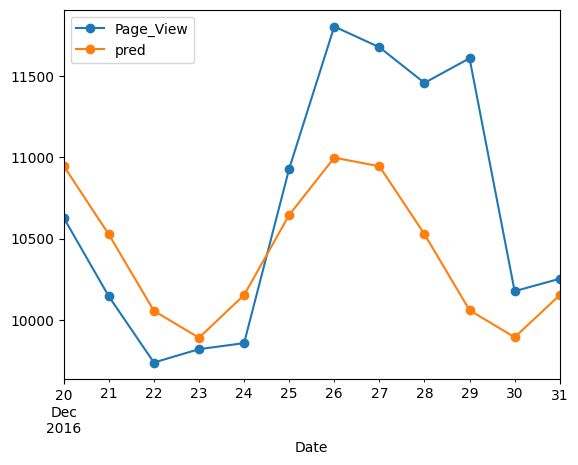

In [247]:
test_x['pred'] = model_fit.forecast(steps=12)  # Forecast for the next 12 months

test_x.plot(style='-o')
performance(test_x['Page_View'], test_x['pred'])

In [254]:
# (p, d, q)
model = SARIMAX(train_x_st.Page_View, order = (15, 1, 10)) # AR(3)
model = model.fit(disp = False)
test_x['pred'] = model.forecast(steps=12)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

MAE : 600.633
RMSE : 709.414
MAPE: 0.055


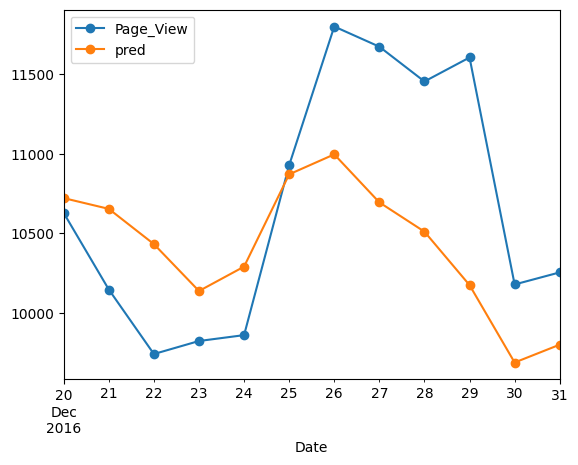

In [255]:
test_x.plot(style='-o')

performance(test_x['Page_View'], test_x['pred'])

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 527.949
RMSE : 666.538
MAPE: 0.047


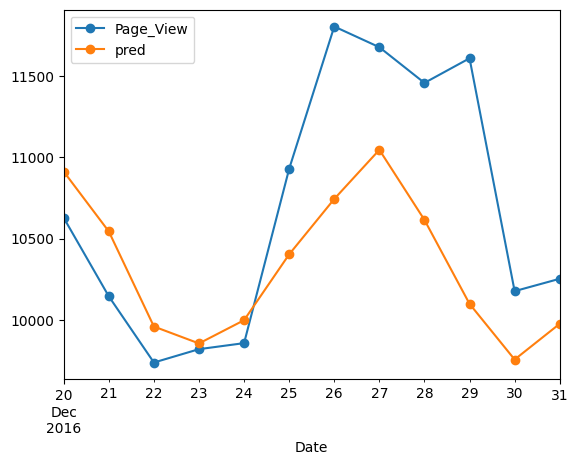

In [256]:
model = SARIMAX(train_x.Page_View, order = (5, 1, 3), seasonal_order = (1, 1, 1, 12))
model = model.fit(disp = False)
test_x['pred'] = model.forecast(steps=12)

test_x.plot(style='-o')
performance(test_x['Page_View'], test_x['pred'])

Forcasting for 12 month using ARIMA and SARIMA mode we achieve the almost MAPE less than 1 and prediction are almost near to actual data

In [257]:
from statsmodels.graphics.tsaplots import plot_acf,  plot_pacf

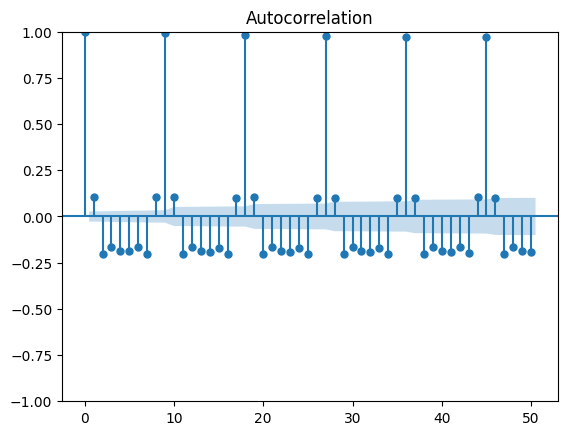

In [258]:
plot_acf(final_df.Page_View, lags=50);

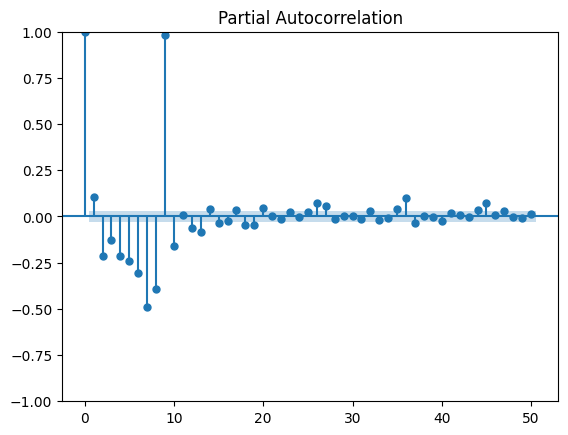

In [259]:
plot_pacf(final_df.Page_View, lags=50);

this data are stationary after performing acf and pacf

In [274]:
def forcast_code(data_fr,language_code):
  train_max_date = data_fr.index[-12]

  train_x = data_fr.loc[data_fr.index < data_fr.index[-12]].copy()
  test_x = data_fr.loc[data_fr.index >= data_fr.index[-12]].copy()

  train_x_st = train_x.copy()

  train_x_st.Page_View = train_x_st.Page_View.diff(1)
  train_x_st.dropna(inplace=True)

  model = SARIMAX(train_x_st.Page_View, order = (20, 1, 15))
  model = model.fit(disp = False)
  test_x['pred'] = model.forecast(steps=12)

  print('-------------------',language_code,'-------------------------')
  test_x.plot(style='-o')
  performance(test_x['Page_View'], test_x['pred'])


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

------------------- commons -------------------------
MAE : 240.337
RMSE : 242.97
MAPE: 0.991


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

------------------- de -------------------------
MAE : 1024.774
RMSE : 1030.42
MAPE: 1.029


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

...

------------------- ru -------------------------
MAE : 957.54
RMSE : 964.666
MAPE: 0.999


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

------------------- www -------------------------
MAE : 81.445
RMSE : 96.742
MAPE: 0.987


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

------------------- zh -------------------------
MAE : 365.771
RMSE : 367.1
MAPE: 0.994


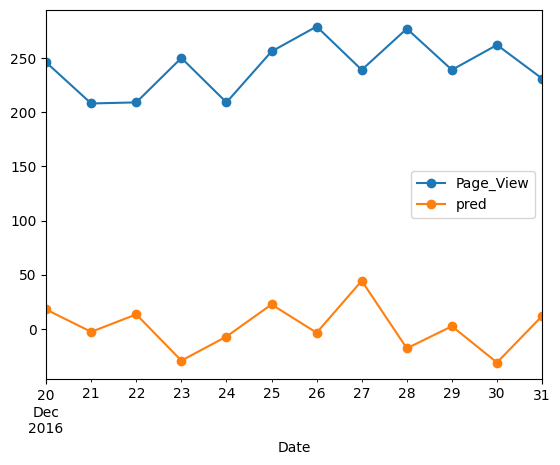

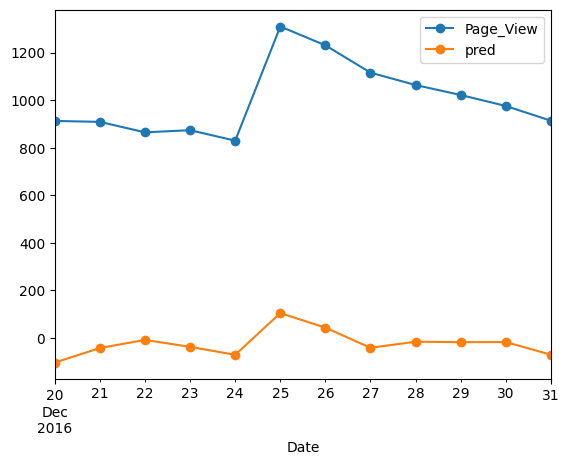

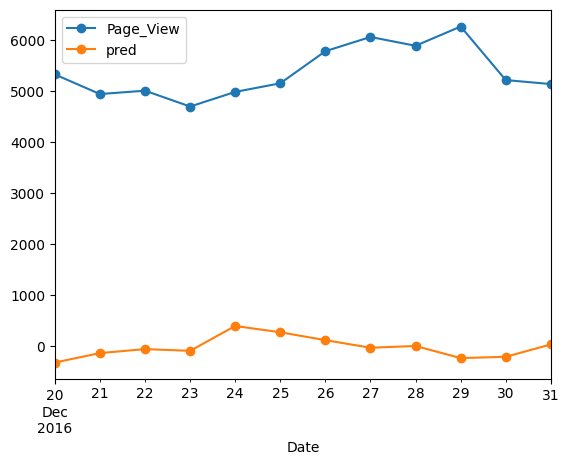

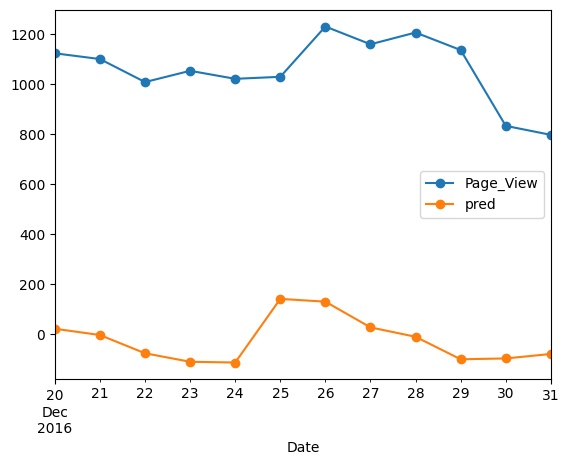

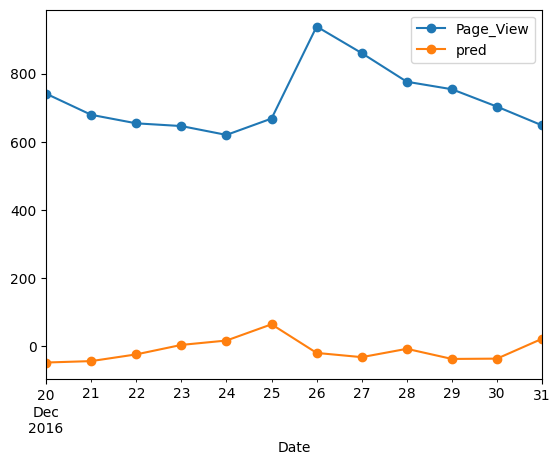

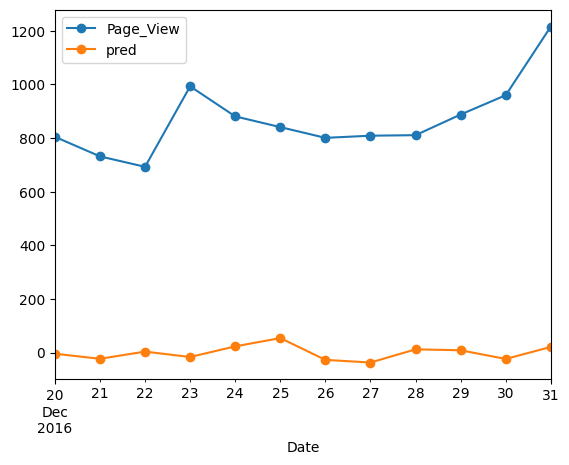

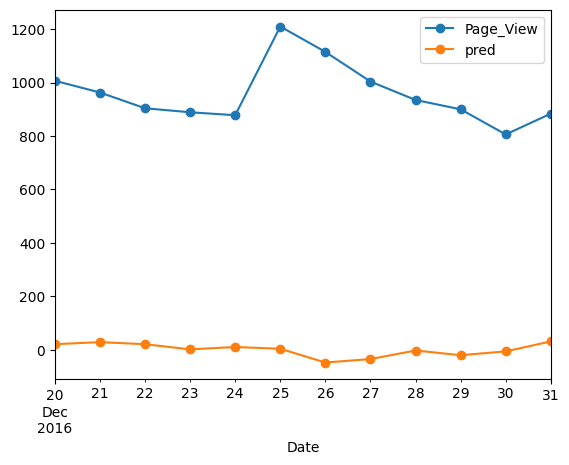

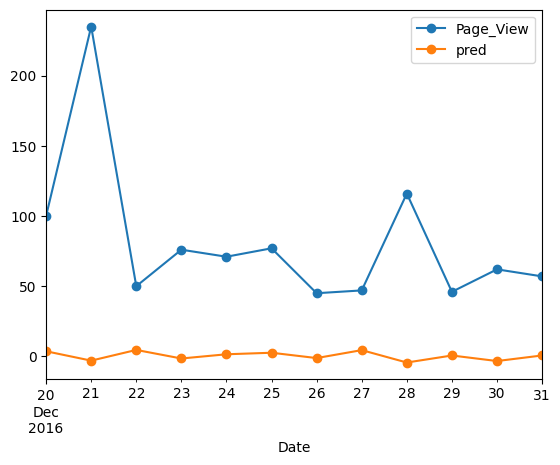

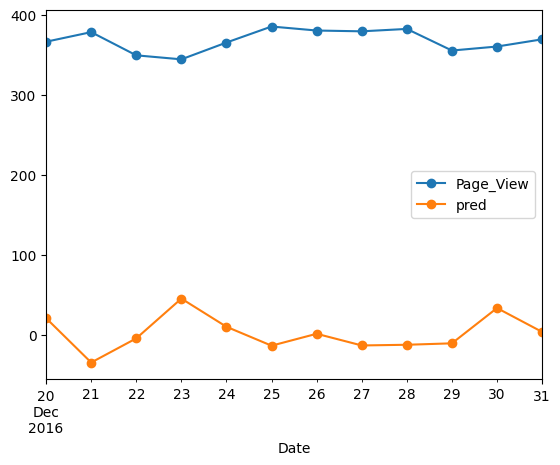

In [275]:
#final_df[final_df['Code']=='fr']

data_code = final_df['Code'].unique()

for i in data_code :
  final_data_i = final_df[final_df['Code']==i]
  final_data_i = final_data_i[['Date','Page_View']]
  final_data_i.set_index('Date', inplace=True)
  forcast_code(final_data_i,i)

Forecasting with Facebook prophet

In [277]:
from prophet import Prophet

In [278]:
exog_df = pd.read_csv('/content/Exog_Campaign_eng.csv')

In [279]:
exog_df.shape

(550, 1)

In [289]:
data_de = data_de.reset_index()

In [295]:
df1 = pd.concat([data_de, exog_df],axis=1)
data_prophet = df1.copy()

data_prophet['ds'] = pd.to_datetime(df1['Date'])
data_prophet['y'] = df1['Page_View']

data_prophet['holiday'] = df1['Exog']

data_prophet = data_prophet[['ds', 'y', 'holiday']]
data_prophet.head()

,ds,y,holiday
0,2015-07-01,9314.0,0
1,2015-07-02,8655.0,0
2,2015-07-03,8146.0,0
3,2015-07-04,8305.0,0
4,2015-07-05,8708.0,0


In [297]:
m = Prophet()
m.fit(data_prophet[['ds', 'y']][:-39])

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwxqza7uv/jcdomlqv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwxqza7uv/ks6fxawy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18242', 'data', 'file=/tmp/tmpwxqza7uv/jcdomlqv.json', 'init=/tmp/tmpwxqza7uv/ks6fxawy.json', 'output', 'file=/tmp/tmpwxqza7uv/prophet_modelrnk6eeet/prophet_model-20241026121129.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:11:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:11:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [298]:
future = m.make_future_dataframe(periods=39, freq="D")
forecast = m.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-07-01,8615.532922,7400.398794,10045.099796,8615.532922,8615.532922,122.179368,122.179368,122.179368,122.179368,122.179368,122.179368,0.0,0.0,0.0,8737.712290
1,2015-07-02,8623.977377,7221.289407,9669.015649,8623.977377,8623.977377,-138.881053,-138.881053,-138.881053,-138.881053,-138.881053,-138.881053,0.0,0.0,0.0,8485.096324
2,2015-07-03,8632.421831,6836.842734,9398.832953,8632.421831,8632.421831,-467.322463,-467.322463,-467.322463,-467.322463,-467.322463,-467.322463,0.0,0.0,0.0,8165.099368
3,2015-07-04,8640.866286,6769.433029,9462.161176,8640.866286,8640.866286,-542.535466,-542.535466,-542.535466,-542.535466,-542.535466,-542.535466,0.0,0.0,0.0,8098.330820
4,2015-07-05,8649.310741,7594.658840,10161.987080,8649.310741,8649.310741,253.622713,253.622713,253.622713,253.622713,253.622713,253.622713,0.0,0.0,0.0,8902.933453


<Axes: >

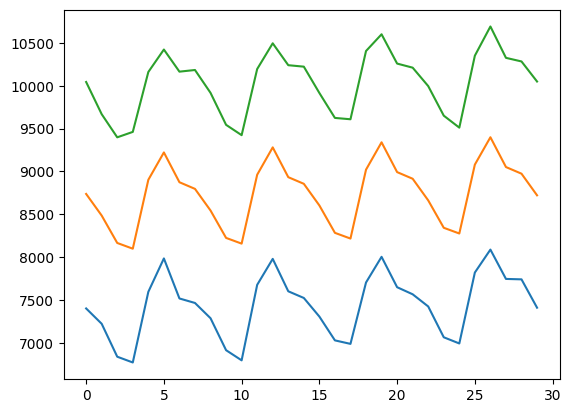

In [299]:
forecast.yhat_lower[:30].plot()
forecast.yhat[:30].plot()
forecast.yhat_upper[:30].plot()

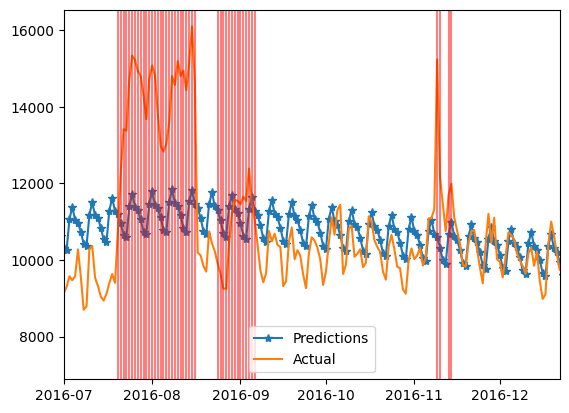

In [302]:
plt.plot(forecast['ds'], forecast['yhat'],'-*', label = 'Predictions')
plt.plot(data_prophet['ds'], data_prophet['y'], label = 'Actual')

for x in data_prophet.query('holiday==1')['ds']:
    plt.axvline(x=x, color='red', alpha = 0.5);
plt.xlim(pd.to_datetime('2016-07-01'), pd.to_datetime('2016-12-22'))
plt.legend()

Questionnaire:

Defining the problem statements and where can this and modifications of this be used?
- Forecast the view of wikipedia for multiple language code. This can be used state wise product sales or country wise sales for product forcasting

Write 3 inferences you made from the data visualizations
- Data is stationary
- En language code have large number of view
- if we perform acf and pcf on this data then also data is stationary

What does the decomposition of series do?
- It provide you the overview of trend, seasonality and residue.

What level of differencing gave you a stationary series?
- Data is already stationary so, no differencing required on this problem. If we did then one differencing is good.

Difference between arima, sarima & sarimax.
- ARIMA is for non-seasonal time series forecasting, while SARIMA extends ARIMA to handle seasonal data. SARIMAX adds the ability to include external variables in the SARIMA model for more comprehensive forecasting.

Compare the number of views in different languages

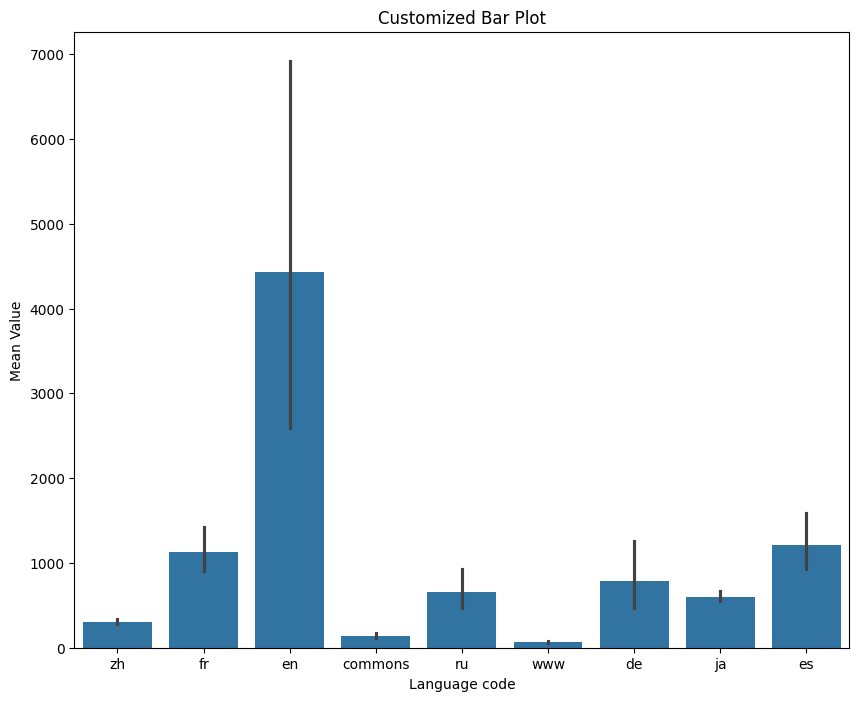
